# AN AUTOMATIC PIPELINE+GUI FOR ANALYSIS OF USG IMAGES FOR THE DIAGNOSIS OF POLYCYSTIC OVARIAN SYNDROME (PCOS)

# BACKGROUND
## What is Polycystic Ovary Syndrome (PCOS)?
 - Presence of the numerous small cysts (fluid-filled sacs) in the ovaries.
## 3 classic features of PCOS
- irregular periods – which means the ovaries do not regularly release eggs (ovulation)
- excess androgen – high levels of "male" hormones in your body , which may cause physical signs such as excess facial or body hair
- 12 or more follicles in the ovary with a diameter of 2-9 mm (cysts)


# RESEARCH PROBLEM
- Currently, follicle detection is still done manually by
Obstetricians and it takes a long time to get accurate result.

- Therefore, a
system that can detect follicles and calculate its size automatically is essential.


# METHODOLOGY

- Employs image thresholding technique to determine the structure of follicles during image binarization followed calculation of the number and diameter of the follicles.

- If there are 12 or more follicles of diameter between 2-9mm, determine the diagnosis of PCOS to be positive , otherwise negative

# Why do I call it an automatic pipeline?
- With my GUI implementation, user can browse the USG image and it automatically processes the image, calculates the no. and size of follicles and returns the the results as PCOS positive or negative (will show at the end)

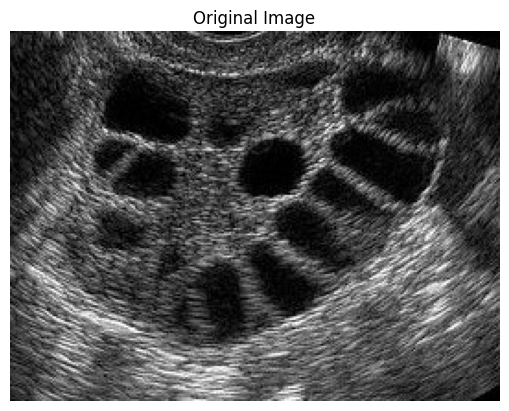

In [174]:
# !pip install scikit-image
import skimage
import skimage.io as io
import skimage.exposure as exposure
import matplotlib.pyplot as plt
from skimage import filters, color, morphology, measure
import numpy as np

def plot_image_and_step(previous_image, current_image, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(previous_image, cmap='gray')
    axes[0].set_title('Previous Step')
    axes[1].imshow(current_image, cmap='gray')
    axes[1].set_title(title)
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


image_path = "/home/mamata/Desktop/Bioimaging/train_small/pco/img3.jpg"
image = io.imread(image_path)

# Display the original image
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.show()

# Histogram Equalization
- improves image contrast


/home/mamata/miniconda3/envs/map4/lib/python3.9/site-packages/skimage/_shared/utils.py:316: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


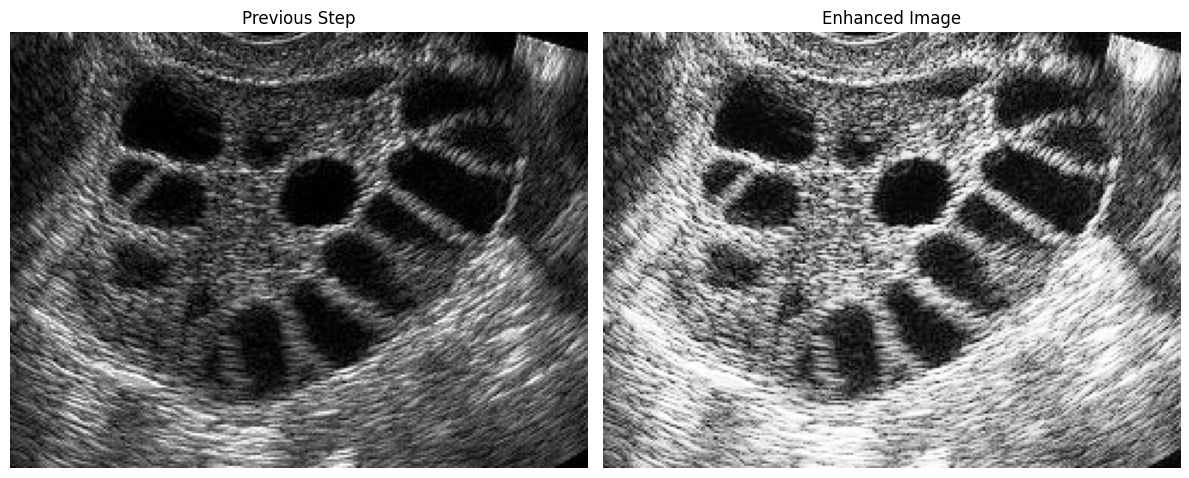

In [175]:
# Increase contrast
enhanced_image = exposure.equalize_hist(image)
# Convert to grayscale for further processing
gray_image = color.rgb2gray(enhanced_image)
plot_image_and_step(image, enhanced_image, 'Enhanced Image')

- Histogram represents the pixel intensity distribution of the image.
- Original image has right skewed intensity distribution, after the equalization, the distribution approaches uniform distribution.

Text(0, 0.5, 'Frequency')

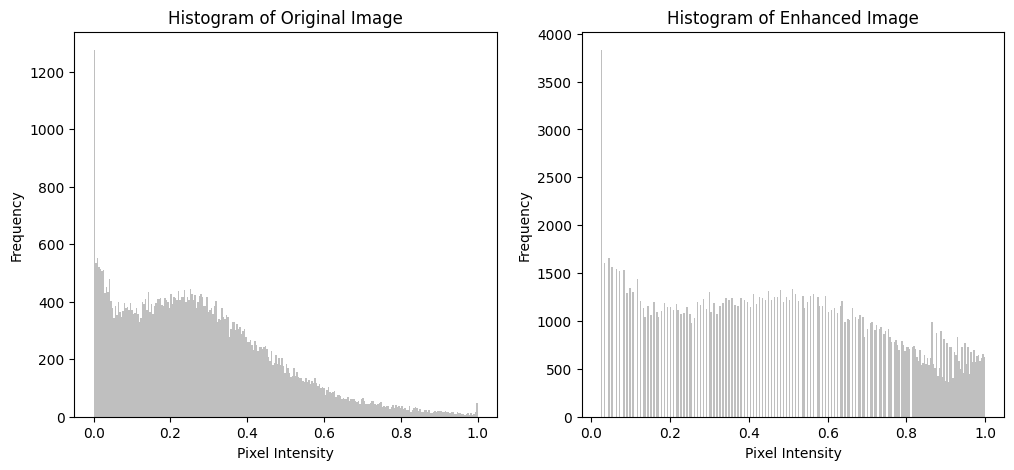

In [176]:
# Convert to grayscale
original_gray = color.rgb2gray(image)
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot histogram of the original image
axes[0].hist(original_gray.ravel(), bins=256, color='gray', alpha=0.5)
axes[0].set_title('Histogram of Original Image')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
# Plot histogram of the enhanced image
axes[1].hist(enhanced_image.ravel(), bins=256, color='gray', alpha=0.5)
axes[1].set_title('Histogram of Enhanced Image')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

# Image Enhancement  (optional)
- The brightness level of an image can be adjusted, eg. multiplying the original image with the scalar value.
- The brightness level of the image is proportional to
the scalar value used.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


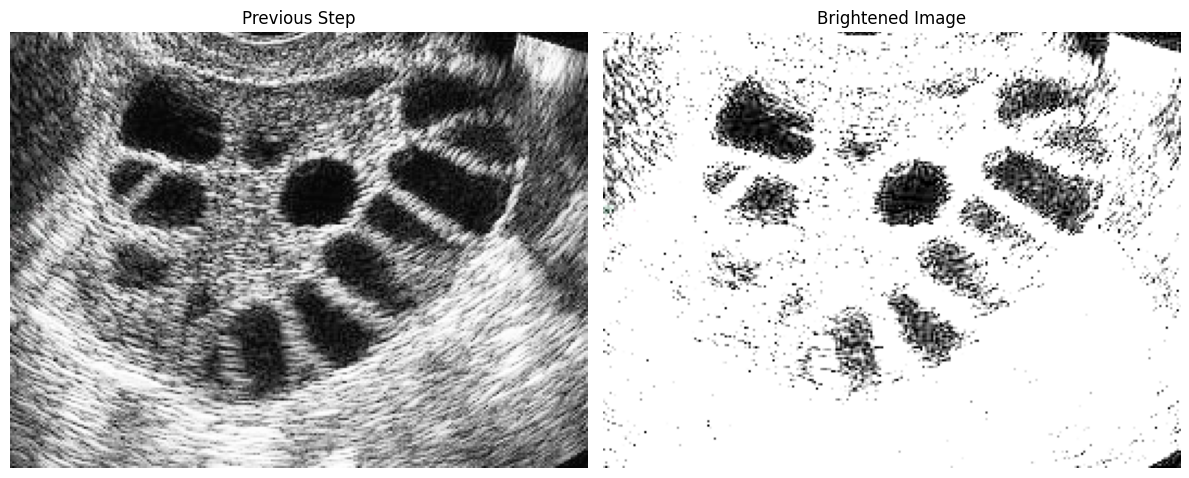

In [177]:
# Increase brightness by multiplying pixel values by a factor
brightened_image = exposure.rescale_intensity(enhanced_image, in_range='image', out_range=(0, 5.0))

#plot ehanced and brightened image
plot_image_and_step(enhanced_image, brightened_image, 'Brightened Image')


# Optimum global thresholding (OTSU)
- Minimize within group variance = maximize between group variance.
-  separates an image into two classes, foreground, and background, based on the grayscale intensity values of its pixels.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


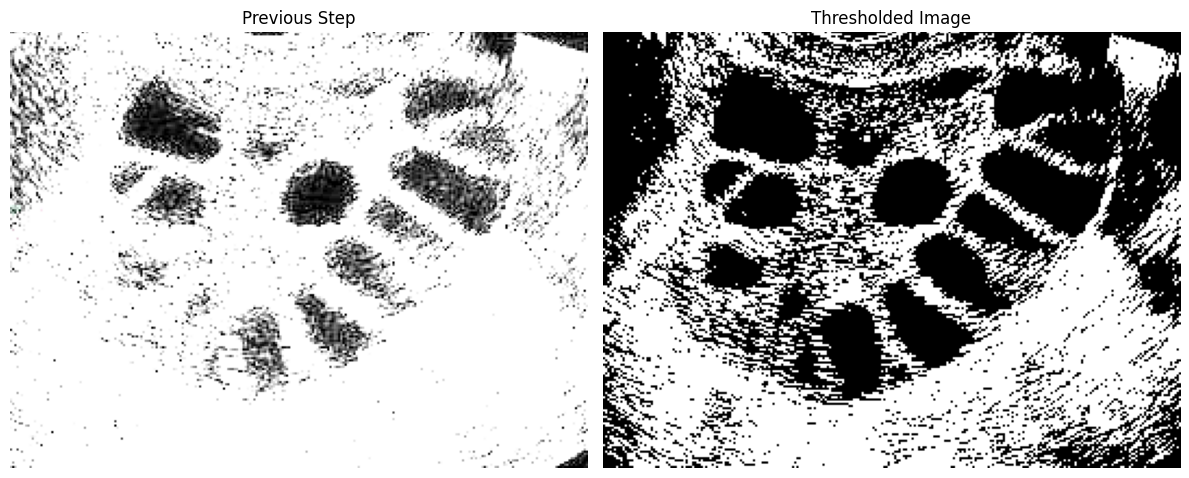

In [178]:
# plot enhanced image and thresholded image
gray_image = color.rgb2gray(brightened_image)
# Apply thresholding
otsu_threshold = filters.threshold_otsu(gray_image)
binary_image = gray_image > otsu_threshold
plot_image_and_step(brightened_image, binary_image, 'Thresholded Image')



# Noise reduction through Binary Closing
- Consists of a dilation followed by an erosion
- Binary Closing can remove small dark spots (i.e. “pepper”) and connect small bright cracks. This tends to “close” up (dark) gaps between (bright) features.

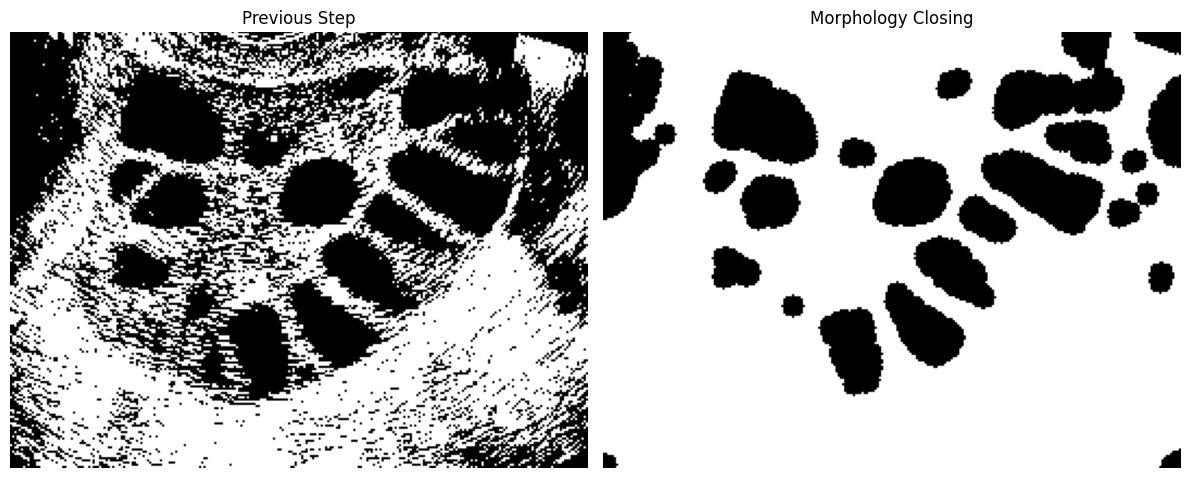

In [179]:
# Perform morphology closing
selem = morphology.disk(5)  # Define structuring element
closed_image = morphology.binary_closing(binary_image, selem)
# Invert the image
inverted_image = np.logical_not(closed_image)
#plot the two images side by side
plot_image_and_step(binary_image, closed_image,  'Morphology Closing')

# Image Inversion and Cleaning
#### Inversion
- In binary image, image negation can be done by using Boolean operator, i.e., not, where the pixel value 0 will change to 1 and the pixel value 1 will change to 0.


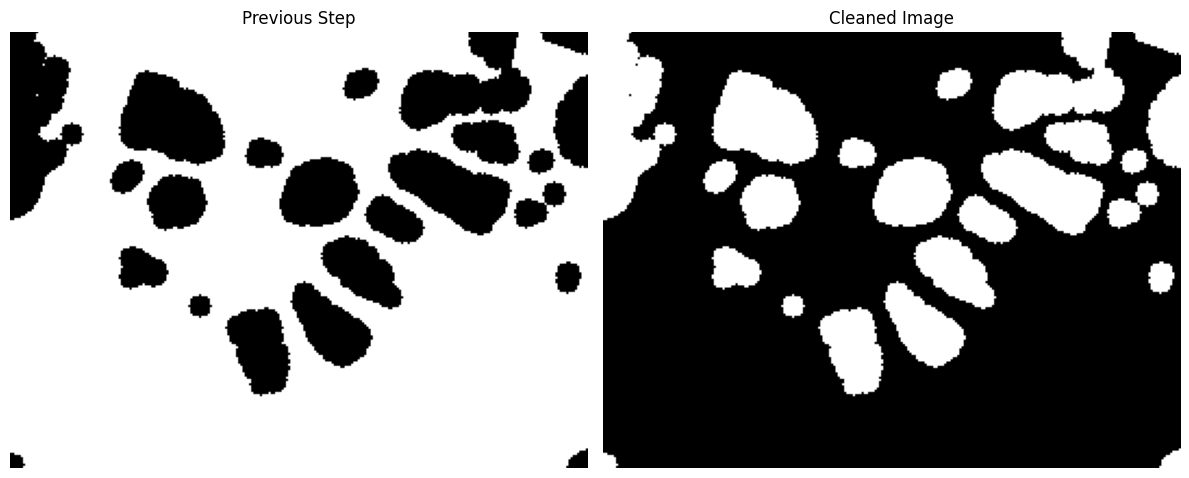

In [180]:
# Label connected components
label_image = measure.label(inverted_image)

# Remove small objects based on diameter and border touching
min_diameter_threshold = 2  # Minimum diameter threshold in mm
min_area_threshold = np.pi * (min_diameter_threshold / 2) ** 2

for region in measure.regionprops(label_image):
    # Calculate diameter
    diameter = region.equivalent_diameter
    # print("diameter", diameter)
    # Check if diameter is less than the threshold or if region touches the border
    if diameter < min_diameter_threshold or region.bbox[0] == 0 or region.bbox[1] == 0 or \
            region.bbox[2] == label_image.shape[0] or region.bbox[3] == label_image.shape[1]:
        label_image[label_image == region.label] = 0

# Convert back to binary image
cleaned_image = label_image > 0
plot_image_and_step(closed_image, inverted_image, 'Cleaned Image')

#### Cleaning
- Label the connected components
- Remove small objects below the diameter of 2mm
- Remove the objects touching the border (tissues)

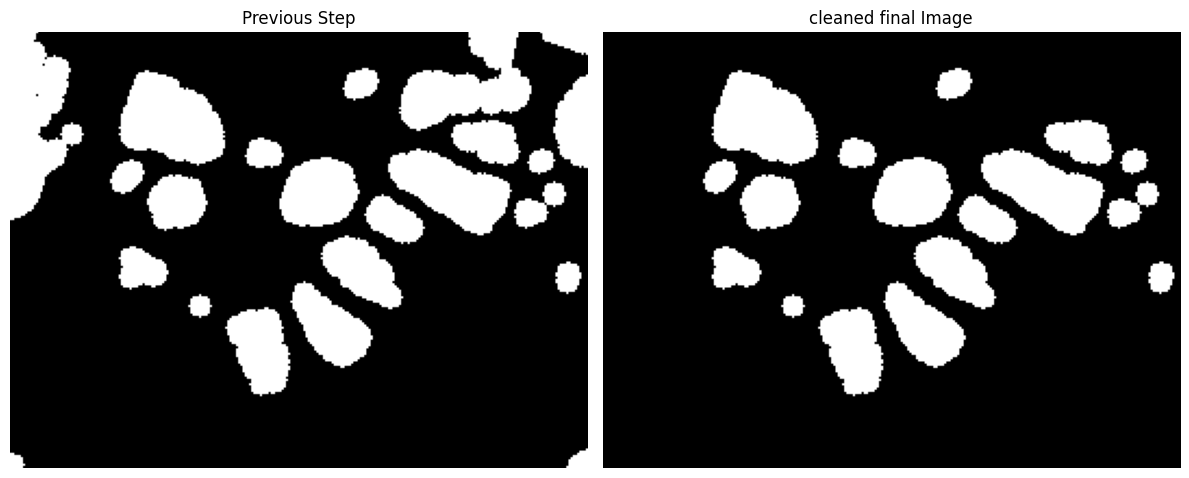

In [190]:
plot_image_and_step(inverted_image, cleaned_image, 'cleaned final Image')

# Stereology : calculation of follicle diameter

- Since follicle detection is based on ultrasound images, the follicle area obtained is still in pixels. So, it needs to be converted into units of millimeters by the formula:

![sample](/home/mamata/Desktop/Bioimaging/Screenshot.png)

- Area value is the number of pixels that make up the follicle 
- the threshold is a divisor value to convert pixel units into millimeters. Usually in the 50-60-pixel ovarian ultrasound image has 1 cm in its original size, this means that every millimeter has 5-6 pixels, so the threshold value used is 5.5 pixels/mm

#### Classification Results 
Indicates whether the patient is PCOS positive or negative based on the number and the size of the follicles contained in Rotterdam criteria, i.e. the presence of twelve or more follicles of 2-9mm in diameter.


In [191]:
# Convert back to binary image
cleaned_image = label_image > 0

# Threshold value for conversion of pixels to millimeters
threshold = 5.5  # pixels/mm

# Label connected components in the cleaned binary image
label_image = measure.label(cleaned_image)

# Get region properties
regions = measure.regionprops(label_image)

# Initialize a list to store follicle diameters
follicle_diameters = []
num_follicles = 0
# Iterate over each labeled region
for region in regions:
    # Calculate area in pixels
    area_pixel = region.area
    
    # Calculate diameter in millimeters
    diameter_mm = np.sqrt((4 * area_pixel) / np.pi) / threshold
    
    # Append the diameter to the list
    follicle_diameters.append(diameter_mm)

        # Check if the diameter is between 2 and 9 mm
    if 2 <= diameter_mm <= 9:
        num_follicles += 1

# Determine if the result is positive or negative
print("num_follicles", num_follicles)
if num_follicles >= 12:
    result = "Positive"
else:
    result = "Negative"

print("Result:", result)

# Print the list of follicle diameters
print("follicle_diameters", follicle_diameters)

num_follicles 16
Result: Positive
follicle_diameters [2.7371737789721826, 7.8739697726113045, 4.466646066249195, 2.8130101192345633, 7.3026532100845865, 2.112249920583703, 6.199087387761011, 2.7062442688056785, 4.780708729889267, 3.243862029368675, 4.046384705739465, 5.5847208995238695, 3.6985717682983807, 2.3660187954639085, 5.878465157042632, 1.8464386370653842, 5.928374186152282]


# An overview of all the steps

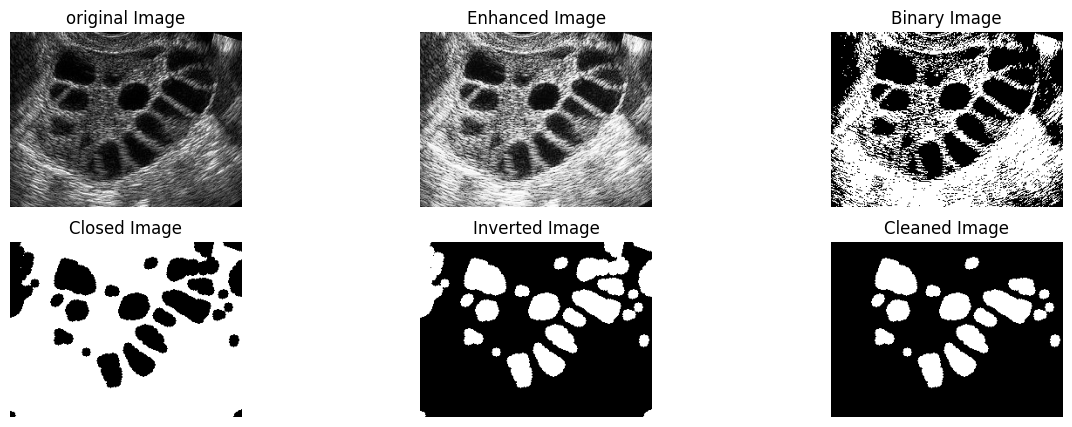

In [192]:
# Plot images from each step
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 5))

ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('original Image')

ax[1].imshow(enhanced_image, cmap='gray')
ax[1].set_title('Enhanced Image')

ax[2].imshow(binary_image, cmap='gray')
ax[2].set_title('Binary Image')

ax[3].imshow(closed_image, cmap='gray')
ax[3].set_title('Closed Image')

ax[4].imshow(inverted_image, cmap='gray')
ax[4].set_title('Inverted Image')

ax[5].imshow(cleaned_image, cmap='gray')
ax[5].set_title('Cleaned Image')

for a in ax:
    a.axis('off')


# Evaluation of performance
- Sensitivity : The ability of the system to detect PCO follicles:
            TP/(TP+FN)
- Specificity: The ability of the system to detect non-PCO follicles:
            TN/(TN+FP)



In [193]:

import os
import csv
import skimage.io as io
import skimage.exposure as exposure
from skimage import filters, color, morphology, measure
import numpy as np

def calculate_follicle_diameters(image_path):
    # Read the image
    image = io.imread(image_path)

    # Increase contrast
    enhanced_image = exposure.equalize_hist(image)
    # Convert to grayscale
    gray_image = color.rgb2gray(enhanced_image)

    # Apply Otsu's thresholding
    otsu_threshold = filters.threshold_otsu(gray_image)
    binary_image = gray_image > otsu_threshold

    # Perform morphology closing
    selem = morphology.disk(5)  # Define structuring element
    closed_image = morphology.binary_closing(binary_image, selem)

    # Invert the image
    inverted_image = np.logical_not(closed_image)

    # Label connected components
    label_image = measure.label(inverted_image)

    # Remove small objects based on diameter and border touching
    min_diameter_threshold = 2  # Minimum diameter threshold in mm
    min_area_threshold = np.pi * (min_diameter_threshold / 2) ** 2

    for region in measure.regionprops(label_image):
        # Calculate diameter
        diameter = region.equivalent_diameter
        # Check if diameter is less than the threshold or if region touches the border
        if diameter < min_diameter_threshold or region.bbox[0] == 0 or region.bbox[1] == 0 or \
                region.bbox[2] == label_image.shape[0] or region.bbox[3] == label_image.shape[1]:
            label_image[label_image == region.label] = 0

    # Convert back to binary image
    cleaned_image = label_image > 0

    # Threshold value for conversion of pixels to millimeters
    threshold = 5.5  # pixels/mm

    # Label connected components in the cleaned binary image
    label_image = measure.label(cleaned_image)

    # Get region properties
    regions = measure.regionprops(label_image)

    # Initialize a list to store follicle diameters
    follicle_diameters = []

    # Iterate over each labeled region
    for region in regions:
        # Calculate area in pixels
        area_pixel = region.area

        # Calculate diameter in millimeters
        diameter_mm = np.sqrt((4 * area_pixel) / np.pi) / threshold

        # Append the diameter to the list
        follicle_diameters.append(diameter_mm)

    return follicle_diameters

def process_images(folder_path):
    results = []
    for subdir in os.listdir(folder_path):
        subfolder = os.path.join(folder_path, subdir)
        if os.path.isdir(subfolder):
            label = 0 if subdir == "normal" else 1
            for filename in os.listdir(subfolder):
                image_path = os.path.join(subfolder, filename)
                basename = os.path.basename(image_path)
                follicle_diameters = calculate_follicle_diameters(image_path)
                num_follicles = sum(1 for diameter in follicle_diameters if 2 <= diameter <= 9)
                result = 1 if num_follicles >= 12 else 0
                results.append([basename, result, label])
    return results

def save_results_to_csv(results, csv_filename):
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Image Path', 'Predicted Label', 'Actual Label'])
        writer.writerows(results)

# Path to the folder containing the images
folder_path = "/home/mamata/Desktop/Bioimaging/data_merged"

# Process images
results = process_images(folder_path)

# Save results to CSV file
csv_filename = "follicle_diameter_results.csv"
save_results_to_csv(results, csv_filename)

print("Results saved to", csv_filename)



/home/mamata/miniconda3/envs/map4/lib/python3.9/site-packages/skimage/_shared/utils.py:316: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


Results saved to follicle_diameter_results.csv


In [194]:
import pandas as pd

# Read the results file
results_df = pd.read_csv("/home/mamata/Desktop/Bioimaging/follicle_diameter_results_otsu.csv")

# Calculate true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN)
TP = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 1)].shape[0]
TN = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 0)].shape[0]
FP = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)].shape[0]
FN = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)].shape[0]

# Create confusion matrix
confusion_matrix = pd.DataFrame({'Predicted Positive': [TP, FP], 'Predicted Negative': [FN, TN]}, index=['Actual Positive', 'Actual Negative'])

# Calculate accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Calculate sensitivity
sensitivity = TP / (TP + FN)

# Calculate specificity
specificity = TN / (TN + FP)

print("Confusion Matsrix:")
print(confusion_matrix)
print("\nAccuracy:", accuracy)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Confusion Matsrix:
                 Predicted Positive  Predicted Negative
Actual Positive                   4                  13
Actual Negative                   2                  41

Accuracy: 0.75
Sensitivity: 0.23529411764705882
Specificity: 0.9534883720930233


#### Too low specificity 
- too less positive samples? 
- Not enough data ?

# Challenges during the project

- Data mostly not available online because of patient privacy
- Dataset is too heterogenous : eg. some images are croped, some are not, not the same dimensions, taken from multiple sources
- Ratios for cropping the full images is  not the same for all images because dimensions differ and so do the position of the follicles on the image which is our area of interest
- Metadata mostly missing
- Sometimes too much noise from the surrounding tissues
-cropping has to be done mannually beforehand for each image





# FUTURE WORK?
- Extract features from the processed images, train machine learning model and compare the results